## Extra Credit -- Drawing plot

In [1]:
# you will be prompted with a window asking to grant permissions
from google.colab import drive
drive.mount("/content/drive")
# fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
import os
datadir = "/content/drive/My Drive/ECE_494_assignments/assignment3"
if not os.path.exists(datadir):
  !ln -s "/content/drive/My Drive/ECE_494_assignments/assignment3" $datadir # TODO: Fill your assignment3 path
os.chdir(datadir)
!pwd

Mounted at /content/drive
/content/drive/My Drive/ECE_494_assignments/assignment3


# Data Setup

The first thing to do is implement a dataset class to load rotated CIFAR10 images with matching labels. Since there is already a CIFAR10 dataset class implemented in `torchvision`, we will extend this class and modify the `__get_item__` method appropriately to load rotated images.

Each rotation label should be an integer in the set {0, 1, 2, 3} which correspond to rotations of 0, 90, 180, or 270 degrees respectively.

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import random

import matplotlib.pyplot as plt


def rotate_img(img, rot):
    if rot == 0: # 0 degrees rotation
        return img
    # TODO: Implement rotate_img() - return the rotated img
    elif rot == 1 or rot == 2 or rot == 3: # 90, 180, 270 degrees rotation
        return transforms.functional.rotate(img, rot*90)
    else:
        raise ValueError('rotation should be 0, 90, 180, or 270 degrees')


class CIFAR10Rotation(torchvision.datasets.CIFAR10):

    def __init__(self, root, train, download, transform) -> None:
        super().__init__(root=root, train=train, download=download, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index: int):
        image, cls_label = super().__getitem__(index)

        # randomly select image rotation
        rotation_label = random.choice([0, 1, 2, 3])
        image_rotated = rotate_img(image, rotation_label)

        rotation_label = torch.tensor(rotation_label).long()
        return image, image_rotated, rotation_label, torch.tensor(cls_label).long()

In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

batch_size = 128

trainset = CIFAR10Rotation(root='./data', train=True,
                                        download=True, transform=transform_train)
print(len(trainset))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

testset = CIFAR10Rotation(root='./data', train=False,
                                       download=True, transform=transform_test)
print(len(testset))
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

50000
10000


Show some example images and rotated images with labels:

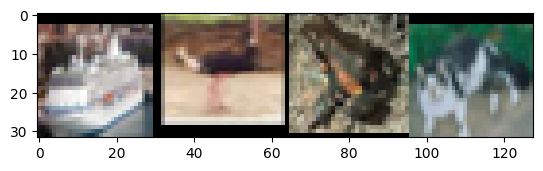

Class labels:  ship  bird  frog  cat  


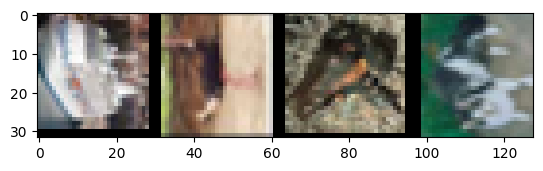

Rotation labels:  270   90    90    90   


In [4]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

rot_classes = ('0', '90', '180', '270')


def imshow(img):
    # unnormalize
    img = transforms.Normalize((0, 0, 0), (1/0.2023, 1/0.1994, 1/0.2010))(img)
    img = transforms.Normalize((-0.4914, -0.4822, -0.4465), (1, 1, 1))(img)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(trainloader)
images, rot_images, rot_labels, labels = next(dataiter)

# print images and rotated images
img_grid = imshow(torchvision.utils.make_grid(images[:4], padding=0))
print('Class labels: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
img_grid = imshow(torchvision.utils.make_grid(rot_images[:4], padding=0))
print('Rotation labels: ', ' '.join(f'{rot_classes[rot_labels[j]]:5s}' for j in range(4)))

# Evaluation code

In [5]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:
import time

def run_test(net, testloader, criterion, task):
    correct = 0
    total = 0
    avg_test_loss = 0.0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for images, images_rotated, labels, cls_labels in testloader:
            if task == 'rotation':
              images, labels = images_rotated.to(device), labels.to(device)
            elif task == 'classification':
              images, labels = images.to(device), cls_labels.to(device)
            # TODO: Calculate outputs by running images through the network
            # The class with the highest energy is what we choose as prediction
            outputs = net(images)
            # Choose the class with the highest energy
            prediction = torch.argmax(outputs, dim=1)

            # Update the parameters for calculating the accuracy
            total += labels.size(0)
            correct += (prediction == labels).sum().item()

            # loss
            avg_test_loss += criterion(outputs, labels)  / len(testloader)
    print('TESTING:')
    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f} %')
    print(f'Average loss on the 10000 test images: {avg_test_loss:.3f}')
    return 100 * correct / total

In [7]:
def adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs=30):
    """Sets the learning rate to the initial LR decayed by 10 every 30 epochs"""
    lr = init_lr * (0.1 ** (epoch // decay_epochs))
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

In [8]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18


In [9]:
import torch.optim as optim


In [10]:
# Both the self-supervised rotation task and supervised CIFAR10 classification are
# trained with the CrossEntropyLoss, so we can use the training loop code.

def train(net, criterion, optimizer, num_epochs, decay_epochs, init_lr, task, trainloader, testloader):

    # Set the initial learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = init_lr

    for epoch in range(num_epochs):  # loop over the dataset multiple times

        running_loss = 0.0
        running_correct = 0.0
        running_total = 0.0
        start_time = time.time()

        net.train()

        for i, (imgs, imgs_rotated, rotation_label, cls_label) in enumerate(trainloader, 0):
            adjust_learning_rate(optimizer, epoch, init_lr, decay_epochs)

            # TODO: Set the data to the correct device; Different task will use different inputs and labels
            if task == 'rotation':
                images, labels = imgs_rotated.to(device), rotation_label.to(device)
            elif task == 'classification':
                images, labels = imgs.to(device), cls_label.to(device)

            # TODO: Zero the parameter gradients
            optimizer.zero_grad()

            # TODO: forward + backward + optimize
            outputs = net(images)
            # the "outputs" is raw logits without softmax, so directly give it to CrossEntropyLoss() function
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # TODO: Get predicted results
            predicted = torch.argmax(outputs, dim=1)

            # print statistics
            print_freq = 100
            running_loss += loss.item()

            # calc acc
            running_total += labels.size(0)
            running_correct += (predicted == labels).sum().item()

            if i % print_freq == (print_freq - 1):    # print every 2000 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_freq:.3f} acc: {100*running_correct / running_total:.2f} time: {time.time() - start_time:.2f}')
                running_loss, running_correct, running_total = 0.0, 0.0, 0.0
                start_time = time.time()

        # TODO: Run the run_test() function after each epoch; Set the model to the evaluation mode.
        net.eval()
        run_test(net, testloader, criterion, task)

    print('Finished Training')
    return run_test(net, testloader, criterion, task)


## 2.1 Fine-tuning on the pre-trained model

In this section, we will load the pre-trained ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [11]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [12]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Load the pre-trained ResNet18 model
net_1 = resnet18(num_classes=10)

# Keep the backbone of the pre-trained model and change the classifier
backbone = torch.load('models/mp3_pretrain_model.pth')
new_state_dict = net_1.state_dict()
backbone = {k: v for k, v in backbone.items() if k in new_state_dict and 'fc' not in k}

# Remain the backbone
new_state_dict.update(backbone)
net_1.load_state_dict(new_state_dict)

# Refresh the classifier
# net.fc = nn.Linear(512, 10)

net_1 = net_1.to(device)
print(net_1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [13]:
# TODO: Freeze all previous layers; only keep the 'layer4' block and 'fc' layer trainable
# First, freeze all layers
for param in net_1.parameters():
    param.requires_grad = True

# Next, unfreeze the 'layer4' block and 'fc' layer
for param in net_1.layer4.parameters():
    param.requires_grad = True
for param in net_1.fc.parameters():
    param.requires_grad = True

In [14]:
# Print all the trainable parameters
params_to_update = net_1.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net_1.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 conv1.weight
	 bn1.weight
	 bn1.bias
	 layer1.0.conv1.weight
	 layer1.0.bn1.weight
	 layer1.0.bn1.bias
	 layer1.0.conv2.weight
	 layer1.0.bn2.weight
	 layer1.0.bn2.bias
	 layer1.1.conv1.weight
	 layer1.1.bn1.weight
	 layer1.1.bn1.bias
	 layer1.1.conv2.weight
	 layer1.1.bn2.weight
	 layer1.1.bn2.bias
	 layer2.0.conv1.weight
	 layer2.0.bn1.weight
	 layer2.0.bn1.bias
	 layer2.0.conv2.weight
	 layer2.0.bn2.weight
	 layer2.0.bn2.bias
	 layer2.0.downsample.0.weight
	 layer2.0.downsample.1.weight
	 layer2.0.downsample.1.bias
	 layer2.1.conv1.weight
	 layer2.1.bn1.weight
	 layer2.1.bn1.bias
	 layer2.1.conv2.weight
	 layer2.1.bn2.weight
	 layer2.1.bn2.bias
	 layer3.0.conv1.weight
	 layer3.0.bn1.weight
	 layer3.0.bn1.bias
	 layer3.0.conv2.weight
	 layer3.0.bn2.weight
	 layer3.0.bn2.bias
	 layer3.0.downsample.0.weight
	 layer3.0.downsample.1.weight
	 layer3.0.downsample.1.bias
	 layer3.1.conv1.weight
	 layer3.1.bn1.weight
	 layer3.1.bn1.bias
	 layer3.1.conv2.weight
	 layer3.1.b

In [15]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
# Only update the parameters that are trainable
trainable_params = filter(lambda p: p.requires_grad, net_1.parameters())
# optimizer = optim.SGD(trainable_params)
optimizer = optim.Adam(trainable_params)

## 2.2 Fine-tuning on the randomly initialized model
In this section, we will randomly initialize a ResNet18 model and fine-tune on the classification task. We will freeze all previous layers except for the 'layer4' block and 'fc' layer.

In [16]:
# Determine GPU or CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [17]:
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18

# TODO: Randomly initialize a ResNet18 model
net_2 = resnet18(num_classes=10)
net_2.to(device)

print(net_2)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
for param in net_2.parameters():
    param.requires_grad = True

In [19]:
# Print all the trainable parameters
params_to_update = net_2.parameters()
print("Params to learn:")
params_to_update = []
for name,param in net_2.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

Params to learn:
	 conv1.weight
	 bn1.weight
	 bn1.bias
	 layer1.0.conv1.weight
	 layer1.0.bn1.weight
	 layer1.0.bn1.bias
	 layer1.0.conv2.weight
	 layer1.0.bn2.weight
	 layer1.0.bn2.bias
	 layer1.1.conv1.weight
	 layer1.1.bn1.weight
	 layer1.1.bn1.bias
	 layer1.1.conv2.weight
	 layer1.1.bn2.weight
	 layer1.1.bn2.bias
	 layer2.0.conv1.weight
	 layer2.0.bn1.weight
	 layer2.0.bn1.bias
	 layer2.0.conv2.weight
	 layer2.0.bn2.weight
	 layer2.0.bn2.bias
	 layer2.0.downsample.0.weight
	 layer2.0.downsample.1.weight
	 layer2.0.downsample.1.bias
	 layer2.1.conv1.weight
	 layer2.1.bn1.weight
	 layer2.1.bn1.bias
	 layer2.1.conv2.weight
	 layer2.1.bn2.weight
	 layer2.1.bn2.bias
	 layer3.0.conv1.weight
	 layer3.0.bn1.weight
	 layer3.0.bn1.bias
	 layer3.0.conv2.weight
	 layer3.0.bn2.weight
	 layer3.0.bn2.bias
	 layer3.0.downsample.0.weight
	 layer3.0.downsample.1.weight
	 layer3.0.downsample.1.bias
	 layer3.1.conv1.weight
	 layer3.1.bn1.weight
	 layer3.1.bn1.bias
	 layer3.1.conv2.weight
	 layer3.1.b

In [20]:
# TODO: Define criterion and optimizer
# Note that your optimizer only needs to update the parameters that are trainable.
criterion = nn.CrossEntropyLoss()
# Only update the parameters that are trainable
trainable_params = filter(lambda p: p.requires_grad, net_2.parameters())
# optimizer = optim.SGD(trainable_params)
optimizer = optim.Adam(trainable_params)

Training with data size: 20
TESTING:
Accuracy of the network on the 10000 test images: 18.74 %
Average loss on the 10000 test images: 2.348
TESTING:
Accuracy of the network on the 10000 test images: 24.35 %
Average loss on the 10000 test images: 5.754
TESTING:
Accuracy of the network on the 10000 test images: 19.40 %
Average loss on the 10000 test images: 10.691
TESTING:
Accuracy of the network on the 10000 test images: 20.39 %
Average loss on the 10000 test images: 10.755
TESTING:
Accuracy of the network on the 10000 test images: 16.49 %
Average loss on the 10000 test images: 12.729
TESTING:
Accuracy of the network on the 10000 test images: 15.29 %
Average loss on the 10000 test images: 9.236
TESTING:
Accuracy of the network on the 10000 test images: 20.57 %
Average loss on the 10000 test images: 9.542
TESTING:
Accuracy of the network on the 10000 test images: 23.63 %
Average loss on the 10000 test images: 5.536
TESTING:
Accuracy of the network on the 10000 test images: 27.83 %
Averag

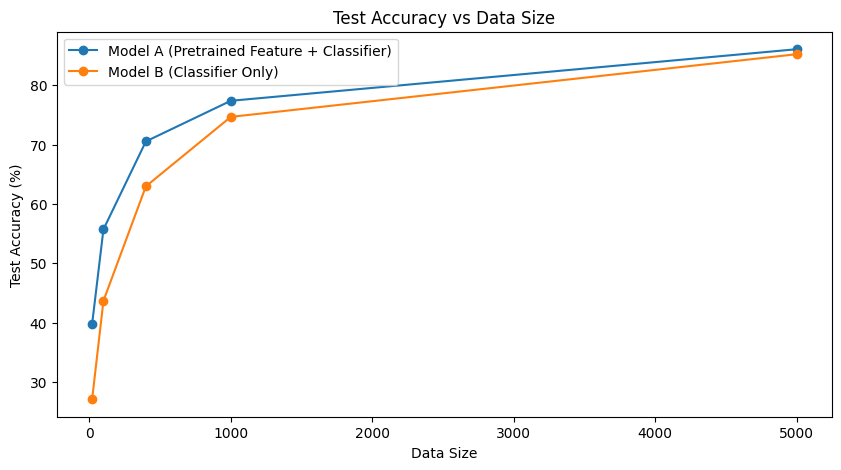

In [21]:
# TODO: Define criterion and optimizer
criterion = nn.CrossEntropyLoss()
# Choose the optimizer as SGD or Adam
# optimizer = torch.optim.SGD(net.parameters())
optimizer_1 = torch.optim.Adam(net_1.parameters())
optimizer_2 = torch.optim.Adam(net_2.parameters())

def get_loader(data_size):
  num_classes = 10
  indices = []
  for label in range(num_classes):
      label_indices = np.where(np.array(trainset.targets) == label)[0]
      selected = np.random.choice(label_indices, data_size, replace=False)
      indices.extend(selected)
  train_subset = torch.utils.data.Subset(trainset, indices)
  trainloader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
  testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0)
  return trainloader, testloader


record_acc_A = []
record_acc_B = []

for data_size in [20, 100, 400, 1000, 5000]:
    print(f"Training with data size: {data_size}")
    trainloader, testloader = get_loader(data_size)
    test_acc_A = train(net_1, criterion, optimizer_1, num_epochs=50, decay_epochs=20, init_lr=0.005, task='classification', trainloader=trainloader, testloader=testloader)
    record_acc_A.append(test_acc_A)
    test_acc_B = train(net_2, criterion, optimizer_2, num_epochs=50, decay_epochs=20, init_lr=0.005, task='classification', trainloader=trainloader, testloader=testloader)
    record_acc_B.append(test_acc_B)
    print(f"Final Test Accuracy - Model A: {test_acc_A:.2f}% | Model B: {test_acc_B:.2f}%\n")

# plot the results
plt.figure(figsize=(10, 5))
plt.plot([20, 100, 400, 1000, 5000], record_acc_A, label='Model A (Pretrained Feature + Classifier)', marker='o')
plt.plot([20, 100, 400, 1000, 5000], record_acc_B, label='Model B (Classifier Only)', marker='o')
plt.xlabel('Data Size')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy vs Data Size')
plt.legend()
plt.show()

